In [1]:
import tensorflow as tf
from keras.models import Model, Sequential
from keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from keras.callbacks import EarlyStopping
from keras.layers.core import SpatialDropout2D
from keras import backend as K
from tensorflow.keras.optimizers import Adam, RMSprop
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
%matplotlib inline
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout
 
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
from keras.models import load_model
import itertools 
filterwarnings('ignore')
np.random.seed(101)
from sklearn.metrics import classification_report, confusion_matrix
import random


def set_seed(seed):
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)


seed = 42
set_seed(seed)

import tensorflow as tf

# Set the seed for reproducibility
tf.random.set_seed(42)

from tensorflow.keras.mixed_precision import experimental as mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

In [2]:
train_dir = "train"
test_dir = "test"
val_dir= "val"


In [3]:
model1 = InceptionResNetV2(include_top=False,input_shape=(224, 224,3), weights='imagenet')
input_shape = (224, 224)

In [4]:
datagen_train = ImageDataGenerator(rescale=1./255,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  horizontal_flip=True,
                                  vertical_flip=False)



datagen_test = ImageDataGenerator(rescale=1./255)

datagen_val=ImageDataGenerator(rescale=1./255)

batch_size = 20
generator_train = datagen_train.flow_from_directory(directory=train_dir,
                                                    target_size=input_shape,
                                                    batch_size=batch_size,  
                                                    class_mode='categorical',
                                                    shuffle=True)

generator_val = datagen_val.flow_from_directory(directory=val_dir,
                                                  target_size=input_shape,
                                                  batch_size=batch_size,
                                                class_mode='categorical',
                                                  shuffle=True)
generator_test=datagen_test.flow_from_directory(directory=test_dir,
                                                  target_size=input_shape,
                                                 batch_size=batch_size,
                                                class_mode='categorical',
                                                 shuffle=False)

Found 3248 images belonging to 4 classes.
Found 409 images belonging to 4 classes.
Found 405 images belonging to 4 classes.


In [5]:
len(model1.layers)

780

In [6]:
def print_layer_trainable():
    for layer in model1.layers[:-1]:
        layer.trainable=False
        print("{0}:\t{1}".format(layer.trainable, layer.name))


print_layer_trainable()

False:	input_1
False:	conv2d
False:	batch_normalization
False:	activation
False:	conv2d_1
False:	batch_normalization_1
False:	activation_1
False:	conv2d_2
False:	batch_normalization_2
False:	activation_2
False:	max_pooling2d
False:	conv2d_3
False:	batch_normalization_3
False:	activation_3
False:	conv2d_4
False:	batch_normalization_4
False:	activation_4
False:	max_pooling2d_1
False:	conv2d_8
False:	batch_normalization_8
False:	activation_8
False:	conv2d_6
False:	conv2d_9
False:	batch_normalization_6
False:	batch_normalization_9
False:	activation_6
False:	activation_9
False:	average_pooling2d
False:	conv2d_5
False:	conv2d_7
False:	conv2d_10
False:	conv2d_11
False:	batch_normalization_5
False:	batch_normalization_7
False:	batch_normalization_10
False:	batch_normalization_11
False:	activation_5
False:	activation_7
False:	activation_10
False:	activation_11
False:	mixed_5b
False:	conv2d_15
False:	batch_normalization_15
False:	activation_15
False:	conv2d_13
False:	conv2d_16
False:	batch_norma

In [7]:
headModel = model1.output
# headModel=layers.GlobalMaxPooling2D()(headModel)
headModel = layers.Flatten()(headModel)
# headModel = Dense(1024, activation="relu")(headModel)
headModel = Dense(512, activation="relu")(headModel)
headModel = Dropout(.4)(headModel)
headModel = Dense(4, activation="softmax")(headModel)
model = Model(inputs=model1.input, outputs=headModel)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 111, 111, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                             

In [8]:
optimizer = Adam(lr=1e-4)
loss = 'categorical_crossentropy'
metrics = ['accuracy','Precision','Recall']


model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

epochs =25

steps_per_epoch = generator_train.n / batch_size
steps_test = generator_test.n / batch_size

# steps_per_epoch = 20
# steps_test = 30
early_stop = EarlyStopping(patience=4)
history = model.fit_generator(generator=generator_train,
                              epochs=epochs,
                              steps_per_epoch=steps_per_epoch,
                              validation_data=generator_val,
                              validation_steps=steps_test
                             )


Epoch 1/25
162/162 [==============================] - 52s 221ms/step - loss: 0.7038 - accuracy: 0.8094 - precision: 0.8205 - recall: 0.7965 - val_loss: 0.2888 - val_accuracy: 0.8949 - val_precision: 0.8988 - val_recall: 0.8900
Epoch 2/25
162/162 [==============================] - 30s 182ms/step - loss: 0.2054 - accuracy: 0.9200 - precision: 0.9236 - recall: 0.9150 - val_loss: 0.1386 - val_accuracy: 0.9535 - val_precision: 0.9534 - val_recall: 0.9511
Epoch 3/25
162/162 [==============================] - 29s 178ms/step - loss: 0.1727 - accuracy: 0.9326 - precision: 0.9340 - recall: 0.9286 - val_loss: 0.1159 - val_accuracy: 0.9609 - val_precision: 0.9609 - val_recall: 0.9609
Epoch 4/25
162/162 [==============================] - 29s 180ms/step - loss: 0.1302 - accuracy: 0.9557 - precision: 0.9573 - recall: 0.9532 - val_loss: 0.1253 - val_accuracy: 0.9535 - val_precision: 0.9535 - val_recall: 0.9535
Epoch 5/25
162/162 [==============================] - 29s 180ms/step - loss: 0.1518 - accura

In [10]:
model.save("InceptionResNetV2.h5")

In [11]:
#Get the accuracy score

train_score = model.evaluate_generator(generator_train)



print("[INFO] accuracy: {:.2f}%".format(train_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(train_score[0] * 100)) 

[INFO] accuracy: 98.03%
[INFO] Loss: 5.30%


In [12]:
#Get the accuracy score

test_score = model.evaluate_generator(generator_test)



print("[INFO] accuracy: {:.2f}%".format(test_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(test_score[0] * 100)) 

[INFO] accuracy: 96.30%
[INFO] Loss: 10.20%


In [13]:

classes=list(generator_train.class_indices.keys())
class_count=len(classes)
print(class_count)
li=[1,2,3,4]

4


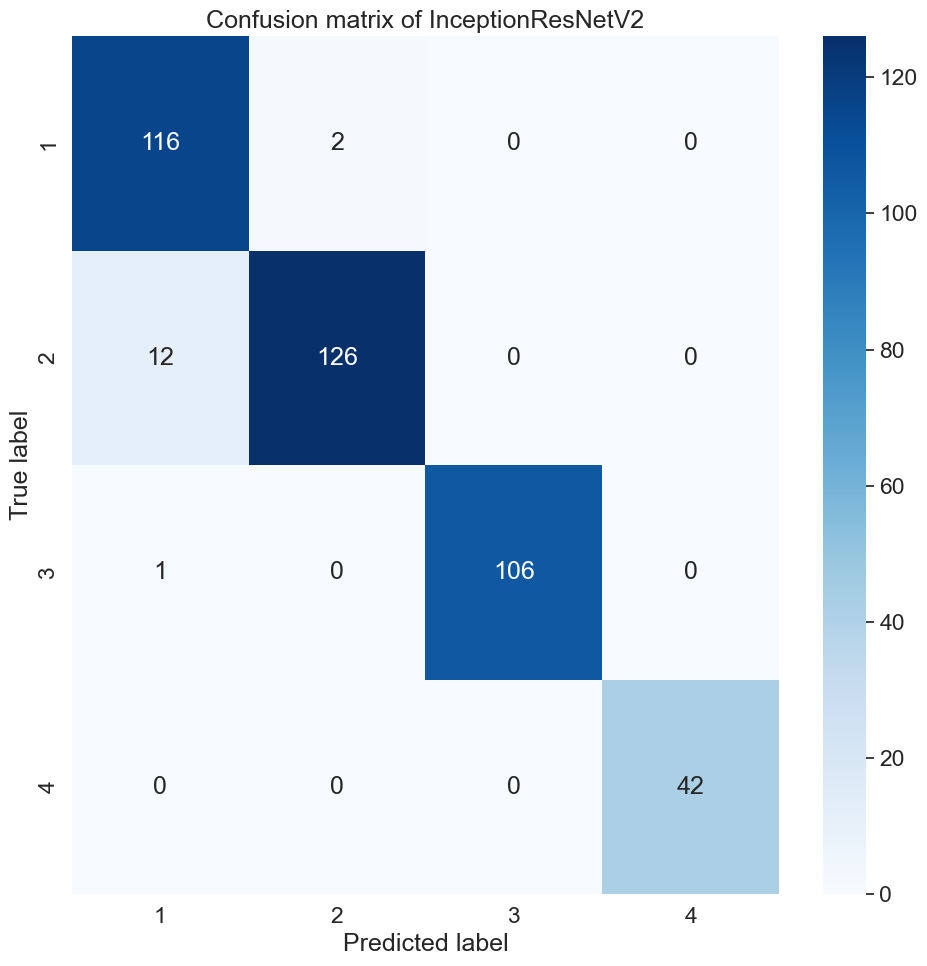

In [14]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
Y_pred = model.predict_generator(generator_test)
y_pred = np.argmax(Y_pred, axis=1)
array = confusion_matrix(generator_test.classes, y_pred)
df_cm = pd.DataFrame(array, index =li,
                  columns = li)
plt.figure(figsize=(10,10))
sn.set(font_scale=1.5)
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix of InceptionResNetV2')
plt.tight_layout()
plt.savefig('InceptionResNetV2_confusion',dpi=200); 
plt.show()



In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(generator_test.classes, y_pred)

0.9629629629629629

In [16]:
target_names = []

for key in generator_train.class_indices:

    target_names.append(key)



print(target_names)

['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


In [17]:
print(classification_report(generator_test.classes, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       118
           1       0.98      0.91      0.95       138
           2       1.00      0.99      1.00       107
           3       1.00      1.00      1.00        42

    accuracy                           0.96       405
   macro avg       0.97      0.97      0.97       405
weighted avg       0.97      0.96      0.96       405



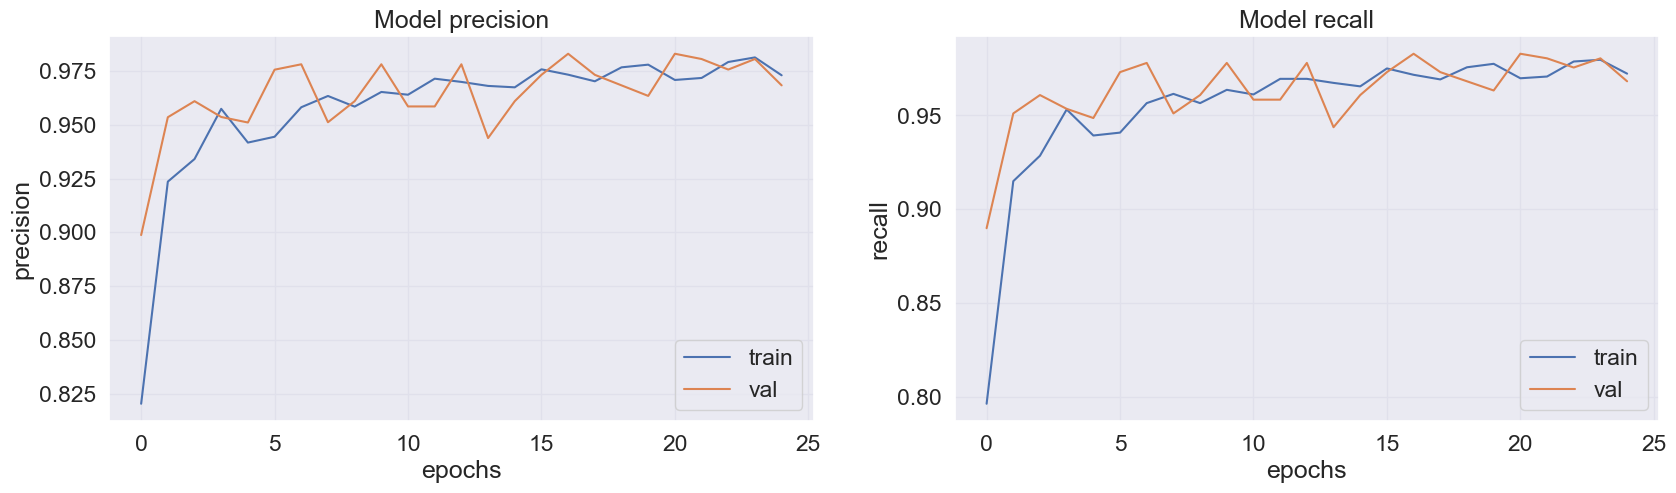

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'])

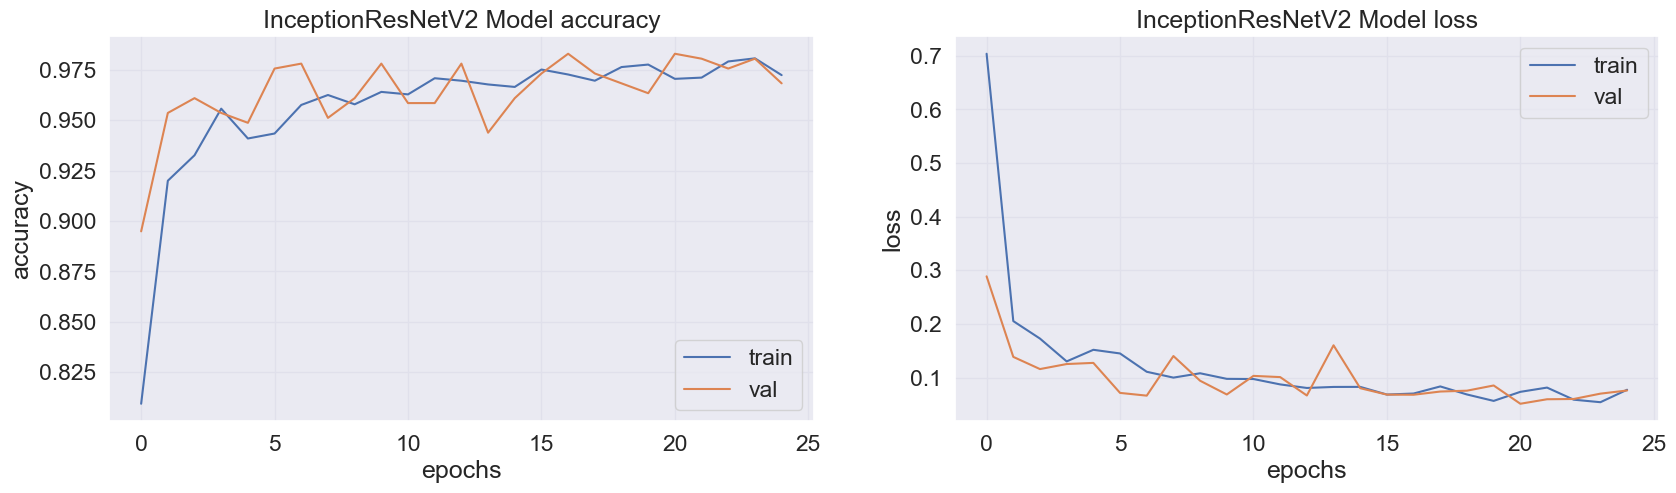

In [19]:

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()
for i, met in enumerate([ 'accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('InceptionResNetV2 Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'],loc='best')
plt.show()

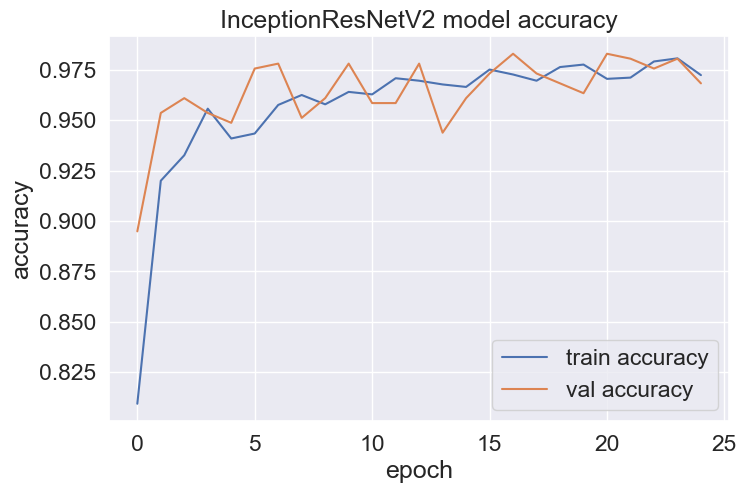

In [20]:

plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['accuracy'],label="train accuracy")
plt.plot(history.history['val_accuracy'],label="val accuracy")
plt.title('InceptionResNetV2 model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('InceptionResNetV2_accuracy',dpi=200); 
plt.show()


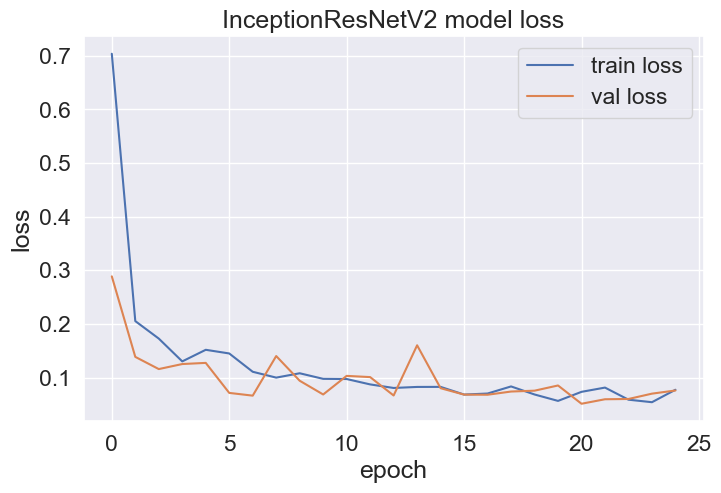

In [21]:
plt.figure(figsize=(8, 5))

ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['loss'],label="train loss")
plt.plot(history.history['val_loss'],label="val loss")
plt.title('InceptionResNetV2 model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('InceptionResNetV2_loss',dpi=200); 
plt.show()